In [1]:
import pandas as pd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# !pip3 install openpyxl # pandas dependancy for excel files



In [ ]:
df = pd.read_excel("./ML_Files/2_Clustering/EXL Shared Partner Data.xlsx")

In [ ]:
df.head()

,Application_Nr,QuoteGeneratedDate,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Effective_Date,Paid_To_Date,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker
0,CUNA11261506,2018-02-07,15000,Void,13.75,Credit Card,Monthly,NaT,NaT,165.0,NaN,NaN,SI Term Band 1,53.0,Liberty
1,CUNA11263501,2018-02-08,10000,Signed,74.80,Credit Card,Monthly,2018-02-08,2022-09-08,897.6,897.6,PAC,SI Whole Life,70.0,Liberty
2,CUNA11264400,2018-02-09,15000,Signed,42.35,Credit Card,Monthly,2018-02-09,2022-10-09,508.2,508.2,DIR,SI Whole Life,54.0,Liberty
3,CUNA11264436,2018-02-09,15000,Signed,57.05,Credit Card,Monthly,2018-02-09,2022-10-09,684.6,684.6,DIR,SI Whole Life,58.0,Liberty
4,CUNA11264525,2018-02-09,10000,Signed,27.80,ACH/PAC,Monthly,2018-02-12,2021-02-12,333.6,333.6,PAC,SI Term Band 1,65.0,Liberty


In [ ]:
df.tail()

,Application_Nr,QuoteGeneratedDate,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Effective_Date,Paid_To_Date,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker
458867,CUNA17318494,2022-09-07,70000,Carrier declined to issue,186.6,ACH/PAC,Monthly,NaT,NaT,2239.2,NaN,NaN,SI Term Band 1,61.0,Ethos
458868,CUNA17318495,2022-09-07,300000,Lapsed Abandoned,68.0,ACH/PAC,Monthly,NaT,NaT,816.0,NaN,NaN,SI Term Band 2,NaN,Ethos
458869,CUNA17318508,2022-09-07,250000,Lapsed Abandoned,55.0,ACH/PAC,Monthly,NaT,NaT,660.0,NaN,NaN,SI Term Band 2,33.0,Liberty
458870,CUNA17318525,2022-09-07,80000,Lapsed Abandoned,89.4,ACH/PAC,Monthly,NaT,NaT,1072.8,NaN,NaN,TAWL,32.0,Liberty
458871,CUNA17318599,2022-09-07,30000,Lapsed Abandoned,294.3,ACH/PAC,Monthly,NaT,NaT,3531.6,NaN,NaN,TAWL,NaN,Liberty


# Mindmap for solving clustering problem
## basic analysis - 
## what is the dataset about
## how many 
## what kind of - basic analysis on each kind
## any missing values - imputation
## categorical to numerical
## feature selection and extraction and further analysis 
## basic plots
## finding optimum k - 
## preprocessing - standardization
## clustering - elbow and silhouette

# some tricks
## after each step validate
## always use functions for so that you can reuse
## always code with giving commentary - speak and explain in english what i am doing while coding
## when writing functions, think in simple terms - like what are the inputs, what should be the output and how should i go from input to output -fill those two first and then figure out the logic in the middle afterwards
## like how keerti purswani does it - she always keeps it very simple and explanatory


In [ ]:
df.head()

,Application_Nr,QuoteGeneratedDate,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Effective_Date,Paid_To_Date,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker
0,CUNA11261506,2018-02-07,15000,Void,13.75,Credit Card,Monthly,NaT,NaT,165.0,NaN,NaN,SI Term Band 1,53.0,Liberty
1,CUNA11263501,2018-02-08,10000,Signed,74.80,Credit Card,Monthly,2018-02-08,2022-09-08,897.6,897.6,PAC,SI Whole Life,70.0,Liberty
2,CUNA11264400,2018-02-09,15000,Signed,42.35,Credit Card,Monthly,2018-02-09,2022-10-09,508.2,508.2,DIR,SI Whole Life,54.0,Liberty
3,CUNA11264436,2018-02-09,15000,Signed,57.05,Credit Card,Monthly,2018-02-09,2022-10-09,684.6,684.6,DIR,SI Whole Life,58.0,Liberty
4,CUNA11264525,2018-02-09,10000,Signed,27.80,ACH/PAC,Monthly,2018-02-12,2021-02-12,333.6,333.6,PAC,SI Term Band 1,65.0,Liberty


In [ ]:
df.columns

Index(['Application_Nr', 'QuoteGeneratedDate', 'OfferCoverageAmount',
       'Offer_Stat_Desc', 'OfferPremiumAmount', 'OfferBillingMethod',
       'Pmnt_Freq_Desc', 'Effective_Date', 'Paid_To_Date', 'Offered_NAP',
       'Issued_NAP', 'CurrentBillMethod', 'ProductType', 'Age_at_AppReceived',
       'PartnerMarker'],
      dtype='object')

In [ ]:
df.shape

(458872, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458872 entries, 0 to 458871
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Application_Nr       458862 non-null  object        
 1   QuoteGeneratedDate   458872 non-null  datetime64[ns]
 2   OfferCoverageAmount  458872 non-null  int64         
 3   Offer_Stat_Desc      458872 non-null  object        
 4   OfferPremiumAmount   458872 non-null  float64       
 5   OfferBillingMethod   458872 non-null  object        
 6   Pmnt_Freq_Desc       458832 non-null  object        
 7   Effective_Date       190605 non-null  datetime64[ns]
 8   Paid_To_Date         190605 non-null  datetime64[ns]
 9   Offered_NAP          458872 non-null  float64       
 10  Issued_NAP           190605 non-null  float64       
 11  CurrentBillMethod    190605 non-null  object        
 12  ProductType          458862 non-null  object        
 13  Age_at_AppRece

df['Application_Nr'].value_counts()

In [ ]:
df['Application_Nr']

0         CUNA11261506
1         CUNA11263501
2         CUNA11264400
3         CUNA11264436
4         CUNA11264525
              ...     
458867    CUNA17318494
458868    CUNA17318495
458869    CUNA17318508
458870    CUNA17318525
458871    CUNA17318599
Name: Application_Nr, Length: 458872, dtype: object

In [ ]:
df['Application_Nr'].value_counts().max()

np.int64(1)

In [ ]:
df.describe()

,QuoteGeneratedDate,OfferCoverageAmount,OfferPremiumAmount,Effective_Date,Paid_To_Date,Offered_NAP,Issued_NAP,Age_at_AppReceived
count,458872,458872.000000,458872.000000,190605,190605,458872.000000,190605.000000,400627.000000
mean,2021-05-29 14:39:36.317578240,41713.013651,75.453247,2021-05-09 20:43:12.611946240,2021-12-18 12:22:37.840559872,891.680556,864.271308,55.467078
min,2018-02-07 00:00:00,1000.000000,0.000000,2018-02-08 00:00:00,2018-02-13 00:00:00,0.000000,0.000000,17.000000
25%,2020-12-02 00:00:00,10000.000000,40.500000,2020-10-17 00:00:00,2021-06-15 00:00:00,485.280000,462.000000,48.000000
50%,2021-07-19 00:00:00,20000.000000,57.300000,2021-06-24 00:00:00,2022-04-01 00:00:00,684.960000,682.680000,58.000000
75%,2022-02-03 00:00:00,45000.000000,90.700000,2022-01-10 00:00:00,2022-09-19 00:00:00,1081.200000,1077.600000,65.000000
max,2022-09-07 00:00:00,300000.000000,5124.000000,2022-11-01 00:00:00,2024-05-01 00:00:00,14496.000000,14496.000000,96.000000
std,NaN,61338.126792,68.232138,NaN,NaN,709.771734,663.639863,13.235514


In [ ]:
df.isna().sum()

Application_Nr             10
QuoteGeneratedDate          0
OfferCoverageAmount         0
Offer_Stat_Desc             0
OfferPremiumAmount          0
OfferBillingMethod          0
Pmnt_Freq_Desc             40
Effective_Date         268267
Paid_To_Date           268267
Offered_NAP                 0
Issued_NAP             268267
CurrentBillMethod      268267
ProductType                10
Age_at_AppReceived      58245
PartnerMarker               0
dtype: int64

In [ ]:
df.columns

Index(['Application_Nr', 'QuoteGeneratedDate', 'OfferCoverageAmount',
       'Offer_Stat_Desc', 'OfferPremiumAmount', 'OfferBillingMethod',
       'Pmnt_Freq_Desc', 'Effective_Date', 'Paid_To_Date', 'Offered_NAP',
       'Issued_NAP', 'CurrentBillMethod', 'ProductType', 'Age_at_AppReceived',
       'PartnerMarker'],
      dtype='object')

In [ ]:
from datetime import datetime
df['quotegenerated_year'] = df['QuoteGeneratedDate'].apply(lambda x: datetime.strftime(x,"%Y"))

In [ ]:
df['quotegenerated_year_month'] = df['QuoteGeneratedDate'].apply(lambda x: datetime.strftime(x,"%Y-%m"))

In [ ]:
df.head(2)

,Application_Nr,QuoteGeneratedDate,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Effective_Date,Paid_To_Date,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker,quotegenerated_year,quotegenerated_year_month
0,CUNA11261506,2018-02-07,15000,Void,13.75,Credit Card,Monthly,NaT,NaT,165.0,NaN,NaN,SI Term Band 1,53.0,Liberty,2018,2018-02
1,CUNA11263501,2018-02-08,10000,Signed,74.80,Credit Card,Monthly,2018-02-08,2022-09-08,897.6,897.6,PAC,SI Whole Life,70.0,Liberty,2018,2018-02


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458872 entries, 0 to 458871
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Application_Nr             458862 non-null  object        
 1   QuoteGeneratedDate         458872 non-null  datetime64[ns]
 2   OfferCoverageAmount        458872 non-null  int64         
 3   Offer_Stat_Desc            458872 non-null  object        
 4   OfferPremiumAmount         458872 non-null  float64       
 5   OfferBillingMethod         458872 non-null  object        
 6   Pmnt_Freq_Desc             458832 non-null  object        
 7   Effective_Date             190605 non-null  datetime64[ns]
 8   Paid_To_Date               190605 non-null  datetime64[ns]
 9   Offered_NAP                458872 non-null  float64       
 10  Issued_NAP                 190605 non-null  float64       
 11  CurrentBillMethod          190605 non-null  object  

In [ ]:
df_yearly_offeredsum = df.groupby(["quotegenerated_year"])['OfferCoverageAmount'].sum()

In [ ]:
df_yearly_offeredsum.head()

quotegenerated_year
2018     179392000
2019    1096232000
2020    2505178000
2021    7213646000
2022    8146486000
Name: OfferCoverageAmount, dtype: int64

In [ ]:
print(df_yearly_offeredsum.index)        # Index values: [2020, 2021, 2022]
print(df_yearly_offeredsum.index.name)   # Index name: 'quotegenerated_year'
print(df_yearly_offeredsum.name)         # Series name: 'OfferCoverageAmount'

Index(['2018', '2019', '2020', '2021', '2022'], dtype='object', name='quotegenerated_year')
quotegenerated_year
OfferCoverageAmount


In [ ]:

# Create a sample series with dummy data
dummy_series = pd.Series([10, 20, 30, 40, 50], name="dummy_data")
dummy_series.index.name = "dummy_index"
print(dummy_series)
print(dummy_series.index)
print(dummy_series.name)
print(dummy_series.index.name)



# Create a sample dataframe with dummy data
data = {
    'A': [1, 2, 3, 4, 5],
    'B': ['apple', 'banana', 'cherry', 'date', 'elderberry'],
    'C': [10.5, 20.3, 30.7, 40.2, 50.1]
}
df_sample = pd.DataFrame(data)
print(df_sample)



dummy_index
0    10
1    20
2    30
3    40
4    50
Name: dummy_data, dtype: int64
RangeIndex(start=0, stop=5, step=1, name='dummy_index')
dummy_data
dummy_index
   A           B     C
0  1       apple  10.5
1  2      banana  20.3
2  3      cherry  30.7
3  4        date  40.2
4  5  elderberry  50.1


In [ ]:
df_yearly_offeredsum['2018']

np.int64(179392000)

In [ ]:
df_yearly_offeredsum.reset_index(name="coverage_sum")

,quotegenerated_year,coverage_sum
0,2018,179392000
1,2019,1096232000
2,2020,2505178000
3,2021,7213646000
4,2022,8146486000


In [ ]:
df_monthly_offeredsum = df.groupby(['quotegenerated_year_month'])['OfferCoverageAmount'].sum().reset_index(name='coverage_monthly_sum')

In [ ]:
df_monthly_offeredsum.head()

,quotegenerated_year_month,coverage_monthly_sum
0,2018-02,3379000
1,2018-03,7988000
2,2018-04,6284000
3,2018-05,6705000
4,2018-06,6586000


<Axes: xlabel='quotegenerated_year_month', ylabel='coverage_monthly_sum'>

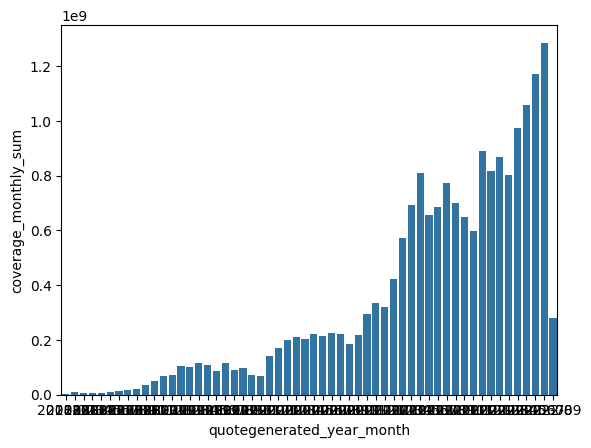

In [ ]:

sns.barplot(x=df_monthly_offeredsum['quotegenerated_year_month'], y=df_monthly_offeredsum['coverage_monthly_sum'])

In [ ]:
df.isna().sum()

Application_Nr                   10
QuoteGeneratedDate                0
OfferCoverageAmount               0
Offer_Stat_Desc                   0
OfferPremiumAmount                0
OfferBillingMethod                0
Pmnt_Freq_Desc                   40
Effective_Date               268267
Paid_To_Date                 268267
Offered_NAP                       0
Issued_NAP                   268267
CurrentBillMethod            268267
ProductType                      10
Age_at_AppReceived            58245
PartnerMarker                     0
quotegenerated_year               0
quotegenerated_year_month         0
dtype: int64

In [ ]:
df = df.dropna(subset='Application_Nr')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 458862 entries, 0 to 458871
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Application_Nr             458862 non-null  object        
 1   QuoteGeneratedDate         458862 non-null  datetime64[ns]
 2   OfferCoverageAmount        458862 non-null  int64         
 3   Offer_Stat_Desc            458862 non-null  object        
 4   OfferPremiumAmount         458862 non-null  float64       
 5   OfferBillingMethod         458862 non-null  object        
 6   Pmnt_Freq_Desc             458822 non-null  object        
 7   Effective_Date             190605 non-null  datetime64[ns]
 8   Paid_To_Date               190605 non-null  datetime64[ns]
 9   Offered_NAP                458862 non-null  float64       
 10  Issued_NAP                 190605 non-null  float64       
 11  CurrentBillMethod          190605 non-null  object       

In [ ]:
df.head(2)

,Application_Nr,QuoteGeneratedDate,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Effective_Date,Paid_To_Date,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker,quotegenerated_year,quotegenerated_year_month
0,CUNA11261506,2018-02-07,15000,Void,13.75,Credit Card,Monthly,NaT,NaT,165.0,NaN,NaN,SI Term Band 1,53.0,Liberty,2018,2018-02
1,CUNA11263501,2018-02-08,10000,Signed,74.80,Credit Card,Monthly,2018-02-08,2022-09-08,897.6,897.6,PAC,SI Whole Life,70.0,Liberty,2018,2018-02


In [ ]:
df = df[['OfferCoverageAmount','Offer_Stat_Desc', 'OfferPremiumAmount', 'OfferBillingMethod',
       'Pmnt_Freq_Desc','Offered_NAP','Issued_NAP', 'CurrentBillMethod', 'ProductType', 'Age_at_AppReceived',
       'PartnerMarker']]

In [ ]:
df.isna().sum()

OfferCoverageAmount         0
Offer_Stat_Desc             0
OfferPremiumAmount          0
OfferBillingMethod          0
Pmnt_Freq_Desc             40
Offered_NAP                 0
Issued_NAP             268257
CurrentBillMethod      268257
ProductType                10
Age_at_AppReceived      58235
PartnerMarker               0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 458862 entries, 0 to 458871
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   OfferCoverageAmount  458862 non-null  int64  
 1   Offer_Stat_Desc      458862 non-null  object 
 2   OfferPremiumAmount   458862 non-null  float64
 3   OfferBillingMethod   458862 non-null  object 
 4   Pmnt_Freq_Desc       458822 non-null  object 
 5   Offered_NAP          458862 non-null  float64
 6   Issued_NAP           190605 non-null  float64
 7   CurrentBillMethod    190605 non-null  object 
 8   ProductType          458852 non-null  object 
 9   Age_at_AppReceived   400627 non-null  float64
 10  PartnerMarker        458862 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 42.0+ MB


In [ ]:
#data = df.dropna()
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 458862 entries, 0 to 458871
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   OfferCoverageAmount  458862 non-null  int64  
 1   Offer_Stat_Desc      458862 non-null  object 
 2   OfferPremiumAmount   458862 non-null  float64
 3   OfferBillingMethod   458862 non-null  object 
 4   Pmnt_Freq_Desc       458822 non-null  object 
 5   Offered_NAP          458862 non-null  float64
 6   Issued_NAP           190605 non-null  float64
 7   CurrentBillMethod    190605 non-null  object 
 8   ProductType          458852 non-null  object 
 9   Age_at_AppReceived   400627 non-null  float64
 10  PartnerMarker        458862 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 42.0+ MB


In [ ]:
df.describe()

,OfferCoverageAmount,OfferPremiumAmount,Offered_NAP,Issued_NAP,Age_at_AppReceived
count,458862.000000,458862.000000,458862.000000,190605.000000,400627.000000
mean,41713.678622,75.454081,891.690270,864.271308,55.467078
std,61338.618720,68.232560,709.775197,663.639863,13.235514
min,1000.000000,0.000000,0.000000,0.000000,17.000000
25%,10000.000000,40.500000,485.280000,462.000000,48.000000
50%,20000.000000,57.300000,684.960000,682.680000,58.000000
75%,45000.000000,90.700000,1081.200000,1077.600000,65.000000
max,300000.000000,5124.000000,14496.000000,14496.000000,96.000000


In [ ]:
def fill_null(data):
    print(data.isna().sum())
    con_cols = data.describe().columns
    print(type(con_cols))
    print(con_cols)
    cat_cols = [i for i in data.columns if i not in data.describe().columns]
    print(cat_cols)
    for i in con_cols:
        data[i].fillna(data[i].median(),inplace = True)
    for i in cat_cols:
        data[i].fillna(data[i].value_counts().index[0], inplace = True)
    print(data.isna().sum())
    
    return data, cat_cols, con_cols
    

In [ ]:
import warnings
warnings.filterwarnings('ignore')

cleaned_df, cat, con = fill_null(df)

OfferCoverageAmount         0
Offer_Stat_Desc             0
OfferPremiumAmount          0
OfferBillingMethod          0
Pmnt_Freq_Desc             40
Offered_NAP                 0
Issued_NAP             268257
CurrentBillMethod      268257
ProductType                10
Age_at_AppReceived      58235
PartnerMarker               0
dtype: int64
<class 'pandas.core.indexes.base.Index'>
Index(['OfferCoverageAmount', 'OfferPremiumAmount', 'Offered_NAP',
       'Issued_NAP', 'Age_at_AppReceived'],
      dtype='object')
['Offer_Stat_Desc', 'OfferBillingMethod', 'Pmnt_Freq_Desc', 'CurrentBillMethod', 'ProductType', 'PartnerMarker']
OfferCoverageAmount    0
Offer_Stat_Desc        0
OfferPremiumAmount     0
OfferBillingMethod     0
Pmnt_Freq_Desc         0
Offered_NAP            0
Issued_NAP             0
CurrentBillMethod      0
ProductType            0
Age_at_AppReceived     0
PartnerMarker          0
dtype: int64


In [ ]:
cat

['Offer_Stat_Desc',
 'OfferBillingMethod',
 'Pmnt_Freq_Desc',
 'CurrentBillMethod',
 'ProductType',
 'PartnerMarker']

In [ ]:
con

Index(['OfferCoverageAmount', 'OfferPremiumAmount', 'Offered_NAP',
       'Issued_NAP', 'Age_at_AppReceived'],
      dtype='object')

In [ ]:
cleaned_df.head(2)

,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker
0,15000,Void,13.75,Credit Card,Monthly,165.0,682.68,DIR,SI Term Band 1,53.0,Liberty
1,10000,Signed,74.80,Credit Card,Monthly,897.6,897.60,PAC,SI Whole Life,70.0,Liberty


In [ ]:
cleaned_df['OfferBillingMethod'].unique()

array(['Credit Card', 'ACH/PAC', 'Direct Bill', 'List Bill', 'Unknown'],
      dtype=object)

In [ ]:
# df_upd =  pd.get_dummies(df)
from sklearn.preprocessing import LabelEncoder

def label_encoding(data, cat):
    le = LabelEncoder()
    for i in cat:
        le.fit(data[i])
        data[i] = le.transform(data[i])
    
    return data

labelled_data = label_encoding(cleaned_df, cat)


    

In [ ]:
labelled_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 458862 entries, 0 to 458871
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   OfferCoverageAmount  458862 non-null  int64  
 1   Offer_Stat_Desc      458862 non-null  int64  
 2   OfferPremiumAmount   458862 non-null  float64
 3   OfferBillingMethod   458862 non-null  int64  
 4   Pmnt_Freq_Desc       458862 non-null  int64  
 5   Offered_NAP          458862 non-null  float64
 6   Issued_NAP           458862 non-null  float64
 7   CurrentBillMethod    458862 non-null  int64  
 8   ProductType          458862 non-null  int64  
 9   Age_at_AppReceived   458862 non-null  float64
 10  PartnerMarker        458862 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 42.0 MB


In [ ]:
labelled_data.head(2)

,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker
0,15000,17,13.75,1,1,165.0,682.68,1,1,53.0,4
1,10000,14,74.80,1,1,897.6,897.60,2,3,70.0,4


# clustering

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=8, random_state=10)

kmeans.fit(labelled_data)
print(kmeans.labels_)
labelled_data['cluster'] = kmeans.predict(labelled_data)

[0 6 0 ... 7 3 4]


In [ ]:
labelled_data.head()

,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker,cluster
0,15000,17,13.75,1,1,165.0,682.68,1,1,53.0,4,0
1,10000,14,74.80,1,1,897.6,897.60,2,3,70.0,4,6
2,15000,14,42.35,1,1,508.2,508.20,1,3,54.0,4,0
3,15000,14,57.05,1,1,684.6,684.60,1,3,58.0,4,0
4,10000,14,27.80,0,1,333.6,333.60,2,1,65.0,4,6


In [ ]:
labelled_data.tail()

,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker,cluster
458867,70000,2,186.6,0,1,2239.2,682.68,1,1,61.0,2,5
458868,300000,11,68.0,0,1,816.0,682.68,1,2,58.0,2,2
458869,250000,11,55.0,0,1,660.0,682.68,1,2,33.0,4,7
458870,80000,11,89.4,0,1,1072.8,682.68,1,4,32.0,4,3
458871,30000,11,294.3,0,1,3531.6,682.68,1,4,58.0,4,4


In [ ]:
labels = kmeans.labels_
labels

array([0, 6, 0, ..., 7, 3, 4], shape=(458862,), dtype=int32)

In [ ]:
clus = pd.DataFrame(data=labels, columns=['clsters'])


In [ ]:
clus.head()

,clsters
0,0
1,6
2,0
3,0
4,6


In [ ]:
clus.value_counts()

clsters
6          166365
0           98432
4           70025
5           53850
3           35199
1           17584
2           12272
7            5135
Name: count, dtype: int64

In [ ]:
labelled_data.head()

,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker,cluster
0,15000,17,13.75,1,1,165.0,682.68,1,1,53.0,4,0
1,10000,14,74.80,1,1,897.6,897.60,2,3,70.0,4,6
2,15000,14,42.35,1,1,508.2,508.20,1,3,54.0,4,0
3,15000,14,57.05,1,1,684.6,684.60,1,3,58.0,4,0
4,10000,14,27.80,0,1,333.6,333.60,2,1,65.0,4,6


In [ ]:
labelled_data = labelled_data.drop(columns=['cluster'])

In [ ]:
from sklearn.preprocessing import StandardScaler

def preprocess(data):
    scaler = StandardScaler()
    # for i in data.columns:
    #     # Reshape the column to a 2D array for StandardScaler
    #     scaler.fit(data[[i]])
    #     data[i] = scaler.transform(data[[i]])
    scaler.fit(data)
    data = scaler.transform(data)
    return data

final_data = preprocess(labelled_data)

print(type(final_data))

<class 'numpy.ndarray'>


In [ ]:
# final_data.head()
final_data

array([[-0.43551205,  1.50779464, -0.90432118, ..., -1.64900282,
        -0.2249572 , -0.45746735],
       [-0.51702686,  0.98958071, -0.00958607, ...,  0.49099809,
         1.1464696 , -0.45746735],
       [-0.43551205,  0.98958071, -0.48516599, ...,  0.49099809,
        -0.14428503, -0.45746735],
       ...,
       [ 3.39568371,  0.47136678, -0.29977043, ..., -0.57900237,
        -1.83840049, -0.45746735],
       [ 0.62418039,  0.47136678,  0.20438826, ...,  1.56099855,
        -1.91907265, -0.45746735],
       [-0.19096764,  0.47136678,  3.2073567 , ...,  1.56099855,
         0.17840362, -0.45746735]], shape=(458862, 11))

## WCSS - within cluster sum of squares - Elbow method

In [ ]:
wcss = []

for i in range(2,40):
    kmeans = KMeans(n_clusters=i, init='k-means++',random_state=10)
    kmeans.fit(final_data)
    wcss.append(kmeans.inertia_)

In [ ]:
wcss

[4228382.017310385,
 3676273.1905149915,
 3275019.880531041,
 3238437.6712407107,
 2835181.8558209515,
 2446171.9674509065,
 2319011.4543748554,
 2182890.670252124,
 2084626.5232780145,
 1952324.9119818741,
 1904047.587763452,
 1855468.5801522026,
 1708488.1542691535,
 1663943.0930884862,
 1601162.9364843299,
 1520810.3537756703,
 1453016.4646462903,
 1409627.070978557,
 1372638.4045050624,
 1317677.1911736324,
 1298775.2766367355,
 1289237.3823678745,
 1248942.782865417,
 1230623.7332251878,
 1203221.9675377656,
 1175381.0406975865,
 1151800.7887606442,
 1131570.9950653643,
 1109693.4058022245,
 1091703.2739970463,
 1074840.926659308,
 1061069.157662767,
 1026609.2156361818,
 989475.4885844052,
 960710.9905319185,
 940232.619505332,
 926045.4167001972,
 923184.6253342456]

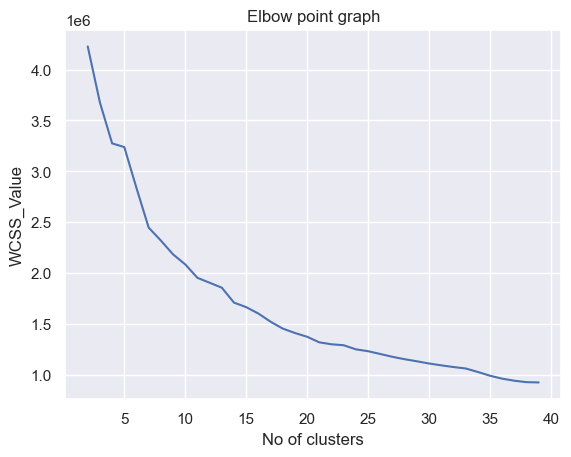

In [ ]:
sns.set_theme()
plt.plot(range(2,40),wcss)
plt.xlabel("No of clusters")
plt.ylabel("WCSS_Value")
plt.title("Elbow point graph")
plt.show()

## Silhouette score - how well the clusters are formed

In [59]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=10)
    ss = silhouette_score(final_data, kmeans.fit_predict(final_data))
    silhouette_scores.append(ss)
silhouette_scores

KeyboardInterrupt: 

In [ ]:
sns.barplot(range(2,10),silhouette_scores)

# Final clustering with optimum k and visualization 

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=10)

kmeans.fit(final_data)
labels = kmeans.predict(final_data)

In [ ]:
x = final_data[:, [0, 2]]
x = x.values

y = labels

x_cetroids = kmeans.cluster_centers_[:,[0,2]]

In [ ]:
x

In [ ]:
y

In [ ]:
# plotting all the clusters and their Centroids

plt.figure(figsize=(8,8))
plt.scatter(X[Y==0,0], X[Y==0,1], s=50, c='green', label='Cluster 1')
plt.scatter(X[Y==1,0], X[Y==1,1], s=50, c='red', label='Cluster 2')
plt.scatter(X[Y==2,0], X[Y==2,1], s=50, c='yellow', label='Cluster 3')
plt.scatter(X[Y==3,0], X[Y==3,1], s=50, c='violet', label='Cluster 4')
plt.scatter(X[Y==4,0], X[Y==4,1], s=50, c='blue', label='Cluster 5')

# plot the centroids
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='cyan', label='Centroids')

plt.title('Customer Groups')
plt.xlabel('OfferCoverageAmount')
plt.ylabel('OfferPremiumAmount')
plt.show()